In [1]:
"Up and running"

'Up and running'

In [2]:
# Third-party modules
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Custom modules
from misc import paths
from misc import style
from misc.logger import logger
from families.domtblout import Domtblout
logger.info('Importing modules completed')

2797273130.py INFO Importing modules completed


In [3]:
# Read the domtblout file
file_path = paths.INTACT / '2026-01-09' / 'hmmscan.domtblout'
df = pd.read_csv(file_path, sep='\t')

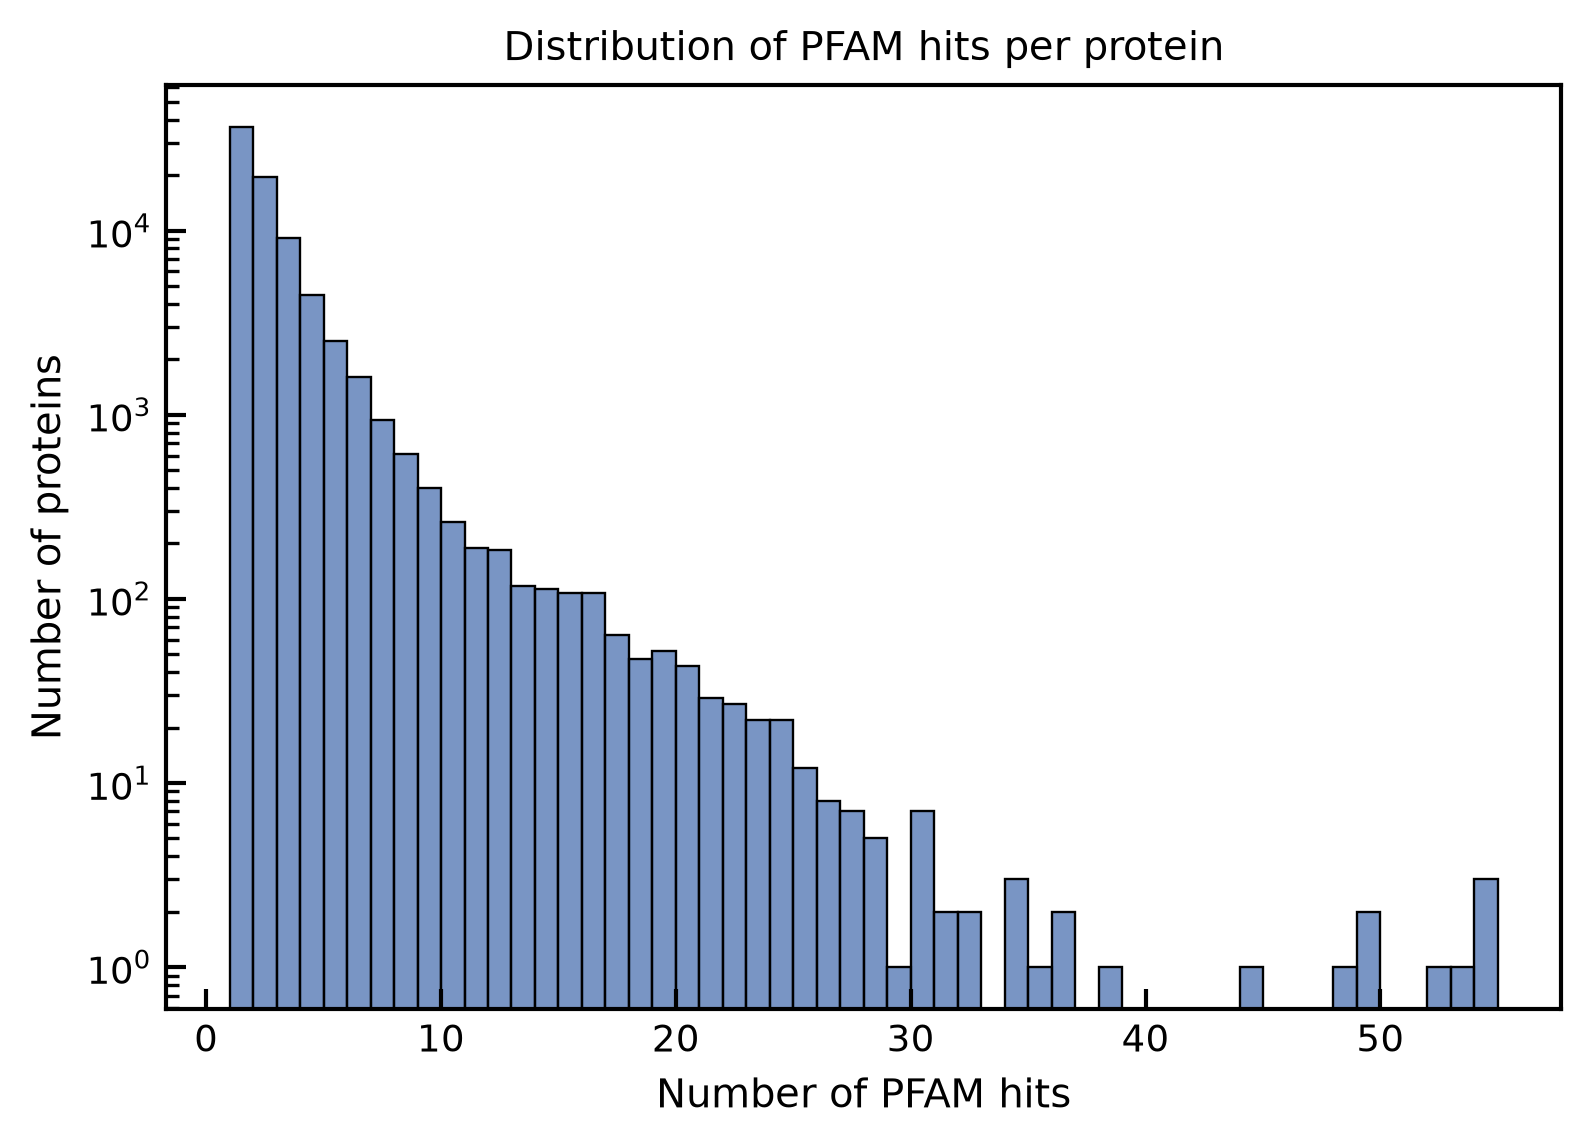

In [4]:
# Distribution of PFAM hits per protein
plt.figure(figsize=(6, 4))
n_domains = df.groupby('query_name').size()
ax = sns.histplot(n_domains, bins=n_domains.max()-1)
ax.set_yscale("log")
plt.title('Distribution of PFAM hits per protein')
plt.xlabel('Number of PFAM hits')
plt.ylabel('Number of proteins')
plt.show()

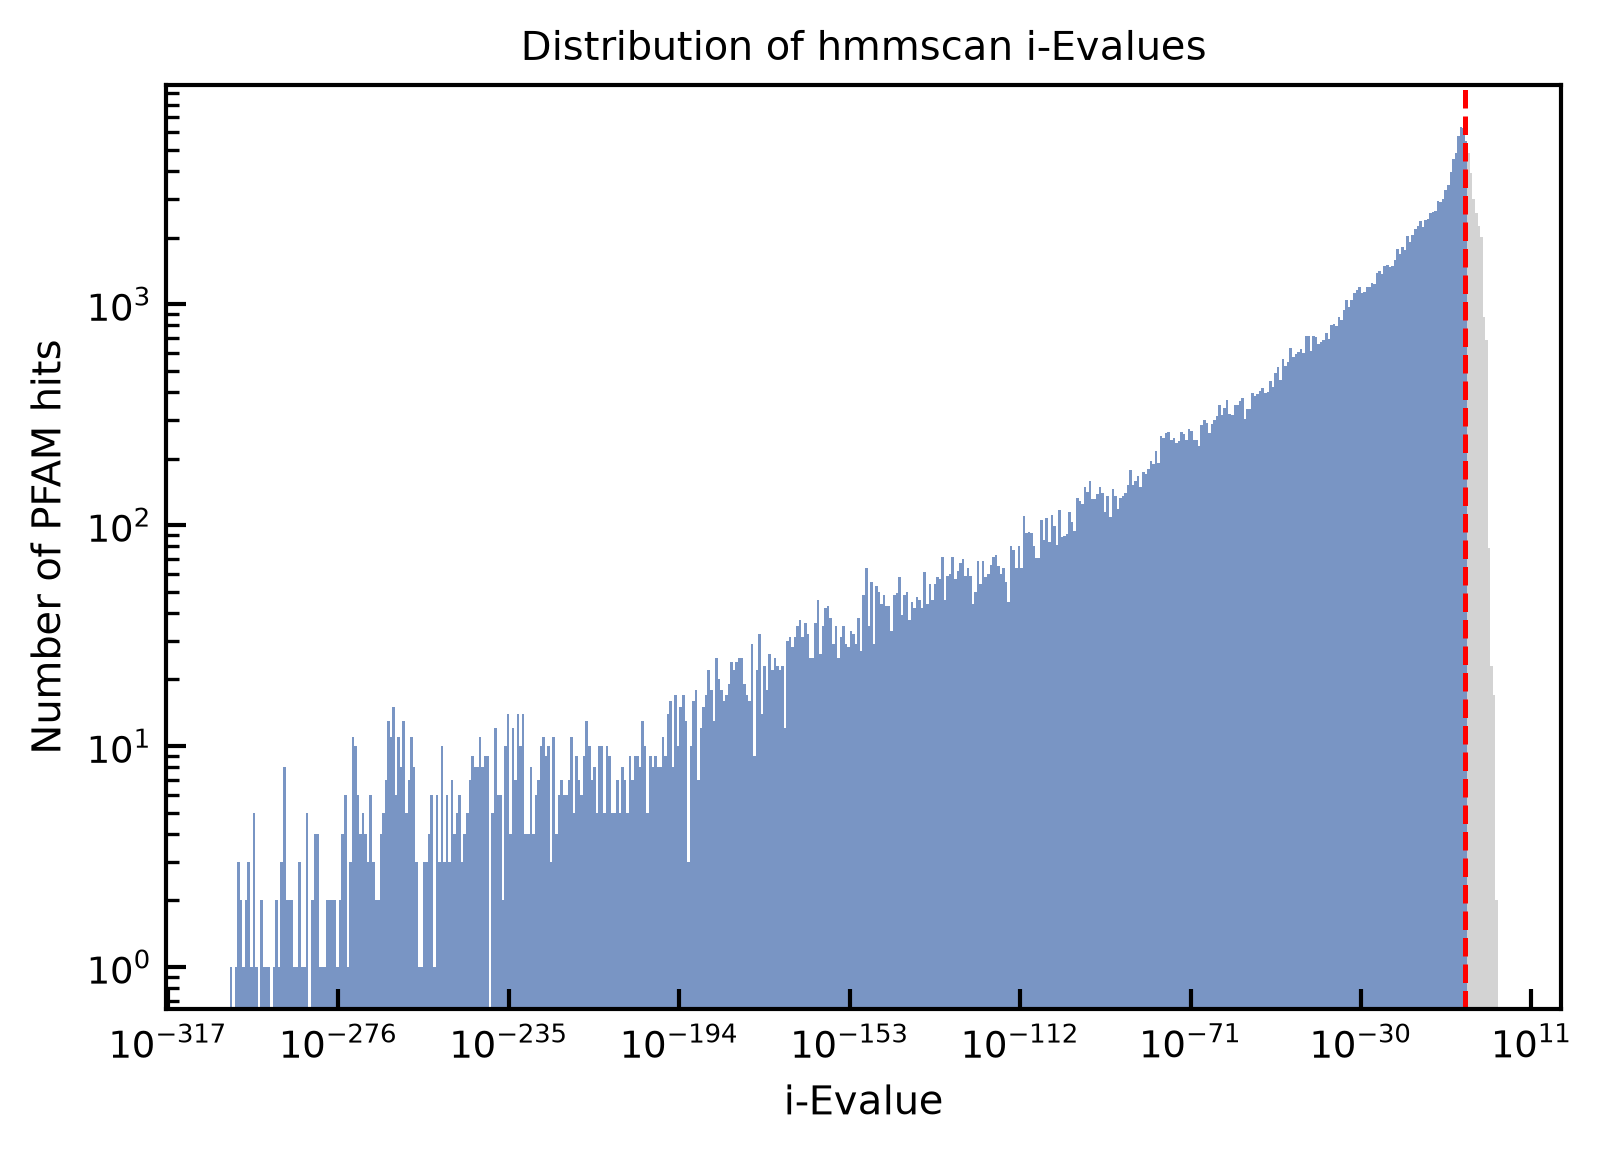

742634385.py INFO Tallest bin is [5.67e-07, 2.32e-06] with 6334 hits.


In [5]:
# Distribution of hmmscan i-evalues

# Non-zero i-evalues
i_evalues = df['i_evalue'].values
i_evalues = np.asarray(i_evalues)
i_evalues = i_evalues[i_evalues > 0]

# Logarithmically spaced bins
bins = np.logspace(
    np.log10(i_evalues.min()),
    np.log10(i_evalues.max()),
    500 # number of bins
)

# Plot histogram of i-evalues
THRESHOLD = 1e-5
plt.figure(figsize=(6, 4))
ax = sns.histplot(i_evalues, bins=bins)
for patch, left, right in zip(ax.patches, bins[:-1], bins[1:]):
    if left >= THRESHOLD:
        patch.set_facecolor('lightgrey')
plt.axvline(THRESHOLD, color='red', linestyle='dashed')
plt.title("Distribution of hmmscan i-Evalues")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("i-Evalue")
plt.ylabel("Number of PFAM hits")
plt.show()

# Which bin has the most hits?
counts, bin_edges = np.histogram(i_evalues, bins=bins)
max_bin_index = np.argmax(counts)
max_bin_range = (bin_edges[max_bin_index], bin_edges[max_bin_index + 1])
logger.info(f"Tallest bin is [{max_bin_range[0]:.2e}, {max_bin_range[1]:.2e}] with {counts[max_bin_index]} hits.")

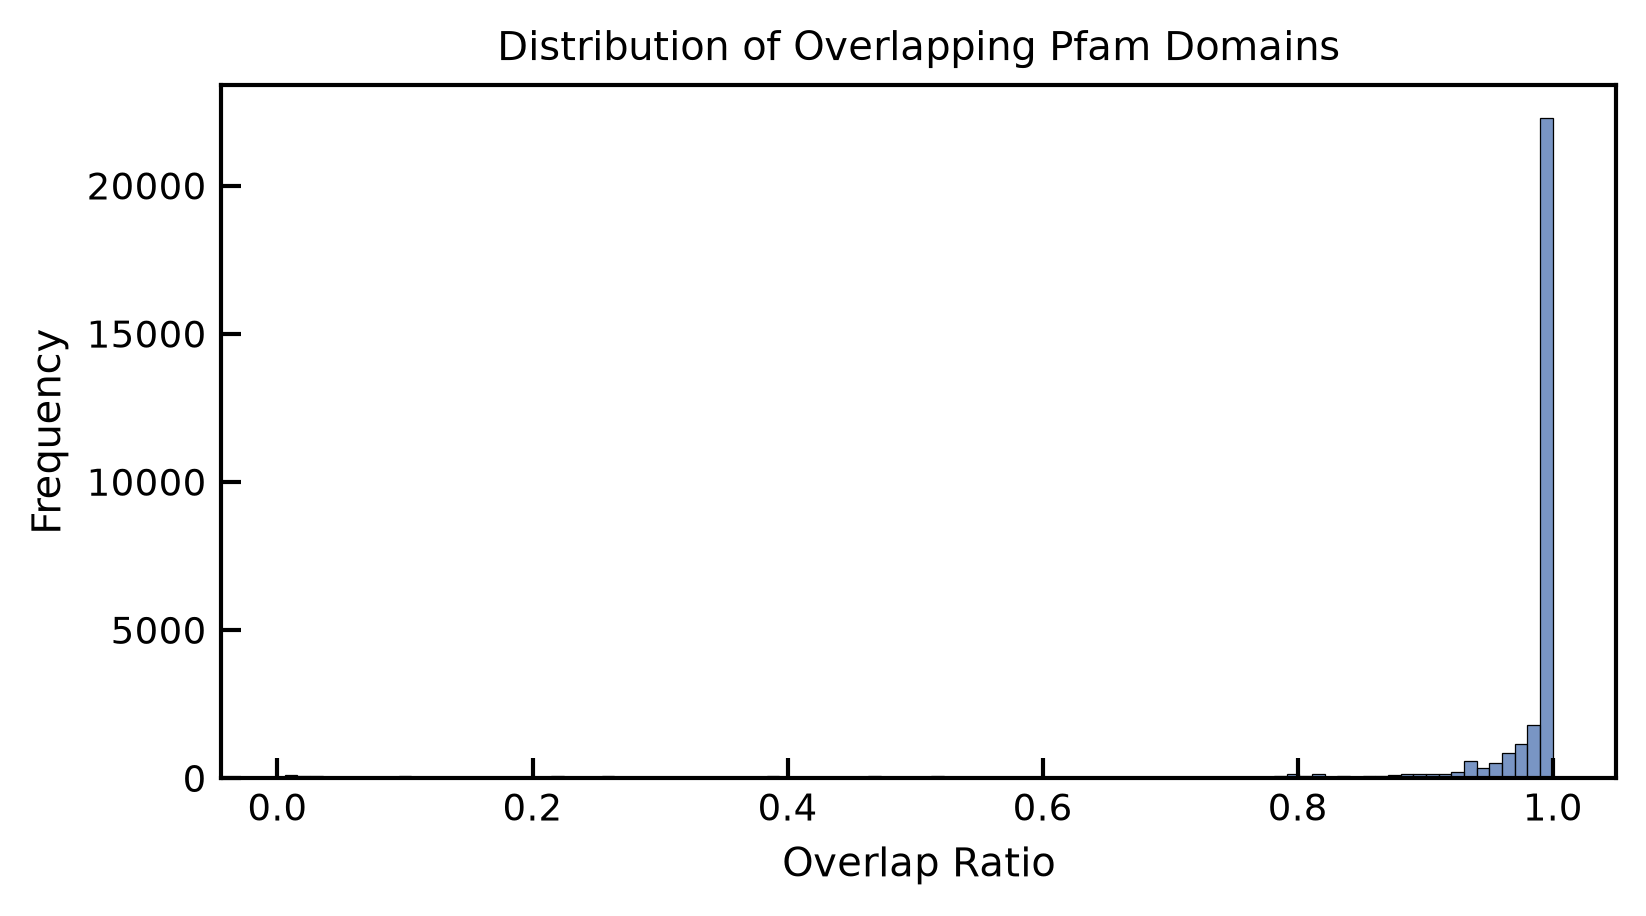

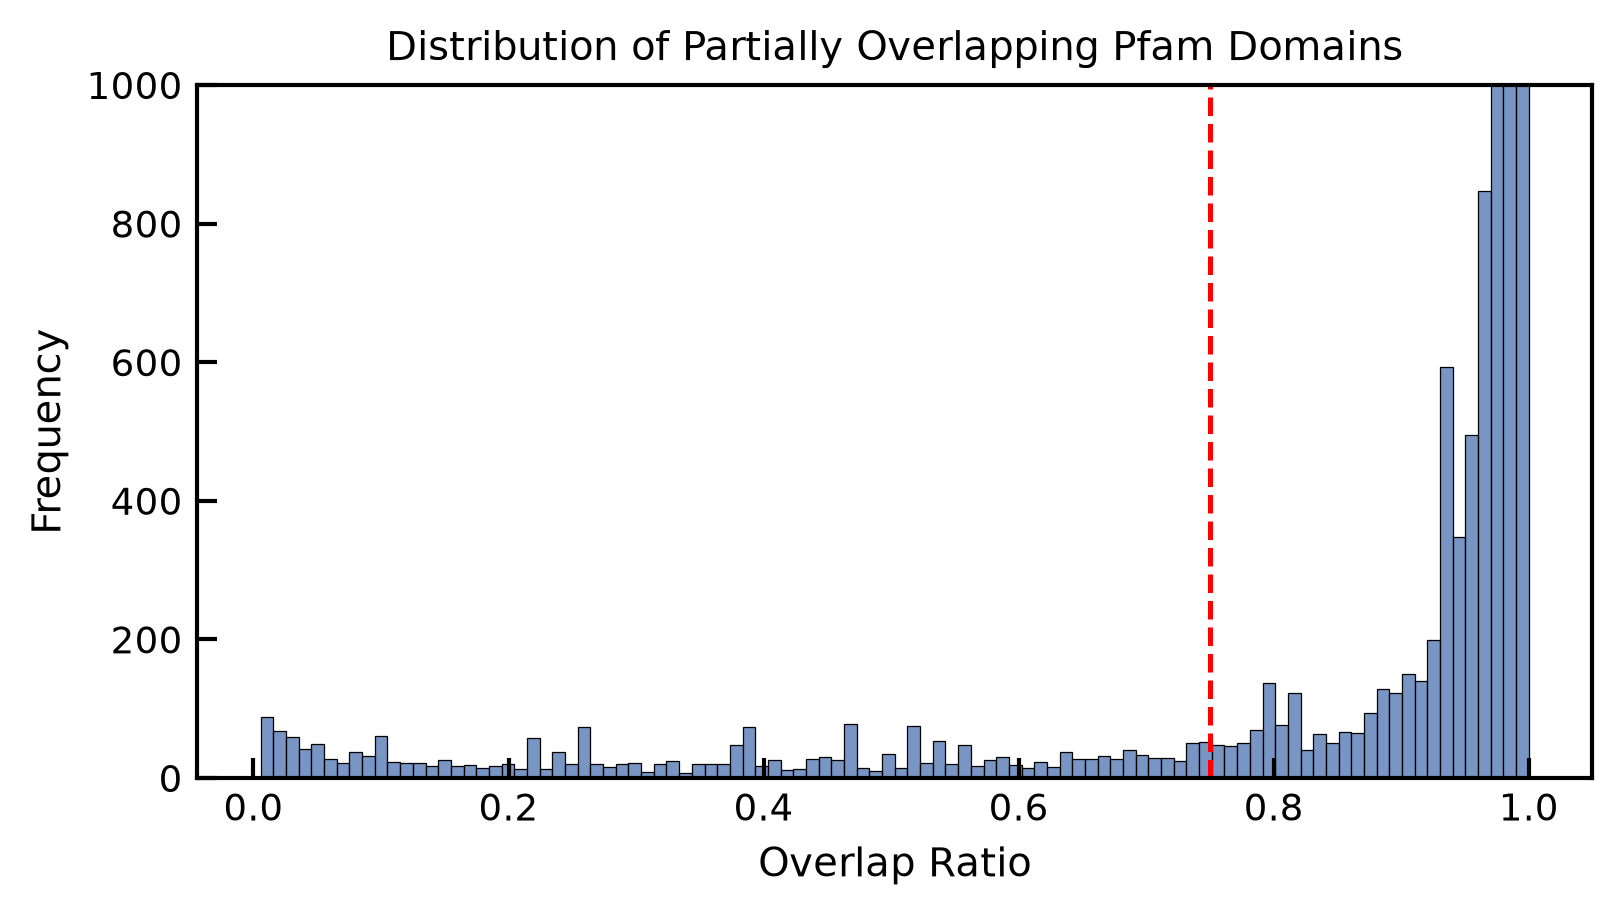

In [5]:
# Distribution of overlapping Pfam domains

# Compute overlapping ratios
domtblout = Domtblout.from_df(df)
domtblout.evalue_filter(field='i_evalue', threshold=1e-5)
query2architecture, overlapping_ratios = domtblout.solve_overlap(threshold=0.75)
overlapping_ratios = np.array(overlapping_ratios)

# General figure
plt.figure(figsize=(6, 3))
sns.histplot(overlapping_ratios, bins=100)
plt.xlabel("Overlap Ratio")
plt.ylabel("Frequency")
plt.title("Distribution of Overlapping Pfam Domains")
plt.show()

# Partial overlap figure
plt.figure(figsize=(6, 3))
sns.histplot(overlapping_ratios, bins=100)
threshold = 0.75
plt.axvline(threshold, color='red', linestyle='dashed')
plt.ylim(0, 1000)
plt.xlabel("Overlap Ratio")
plt.ylabel("Frequency")
plt.title("Distribution of Partially Overlapping Pfam Domains")
plt.show()